# Random forest model
The file loaded here is a file where predictions have been made on 218 antibodies (called the biobhi data set). These predictions have then been computed into scores. Each row represents an antibody and each column is a tool. THere is one column for the antibody name, and one column with ADA percantage, this is clinically measured data, and it is used as the response variable.\
In this script the antibodies are divided into 3 groups of low, medium and high ADA percantage. \
This is done because predictions made previously (in the model selection scripts) are not showing good results. Especially are they bad at targeting antibodies that have high ADA percentage. One reason for this could be that there are not as many antibdoies with high ADA and therefor the data gets sqewed and the predictions worse. This is especilly important because it is of interest to catch the antibodies with high ADA. 


In [28]:
# load libaries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score


In [37]:
# Load table with all computed scores for all tools
computed_scors_biophi = pd.read_csv("../model_selection/biophi_dataSet/all_predictors_217AB(biophidata).csv")
computed_scors_biophi 

,antibody,ADA_percentage,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC1_pep14_percentile,netMHC1_pep14_immunogenicity_score,netMHC1_pep14_preProcess,netMHC_II_pep12_percentile,netMHC_II_pep12_immunogenicity_score,netMHC_II_pep12_combined_immunogen,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_combined_immunogen,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.0,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,37.209302,10.229277,94.757871,35.714286,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.1,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,30.232558,9.043928,95.568972,37.209302,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.5,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,32.558140,9.043928,96.271372,39.534884,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.4,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.579673,99.620457,33.333333,9.130060,96.304235,34.883721,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.0,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,31.818182,7.665805,96.583658,25.581395,0.095804,31.544048,39,0.924883,0.835681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,zalutumumab,0.0,3.191138,42.410714,-3.394748,0.219855,38.356164,-3.521994,6.584362,99.248820,33.333333,7.744108,95.617020,43.181818,0.117738,25.100465,42,0.930556,0.805556
214,zolbetuximab,0.0,3.039362,39.461883,-3.458596,0.220863,36.238532,-3.593007,6.649832,99.524084,25.581395,9.090909,96.301316,40.909091,0.111857,27.603953,44,0.562791,0.334884
215,zolimomab,85.7,3.618365,33.179724,-3.398370,0.296995,31.603774,-3.558859,6.287683,99.571700,34.883721,8.785530,95.436142,37.209302,0.157254,25.740732,45,0.373206,0.095694
216,moab_81c6,100.0,3.686945,42.081448,-3.399031,0.257202,39.814815,-3.552895,8.585859,99.434207,29.545455,9.991387,95.444688,32.558140,0.152478,26.621190,49,0.516432,0.352113


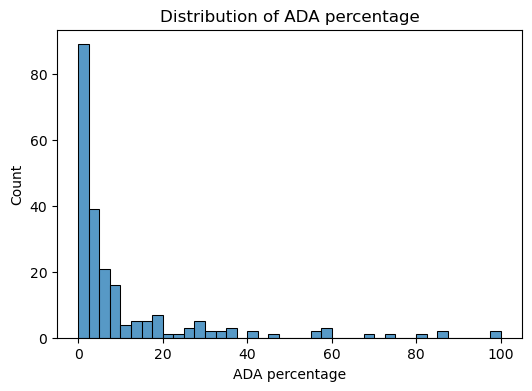

In [38]:
# Plot distribution of ADA percantage among the antibodies

plt.figure(figsize=(6,4))
sns.histplot(computed_scors_biophi['ADA_percentage'], bins=40)

plt.title('Distribution of ADA percentage')
plt.xlabel('ADA percentage')
plt.ylabel('Count')
plt.show()

In [39]:
# Add a column to the computed_scors_biophi df called "ADA group", 
# in this column each row is assigned "low", "medium" or "high"
# low is rows with ADA_percentage below 10
# medium is rows wtih ADA_percentage 10 to 30
# high is rows with ADA_percentage above 30
computed_scors_biophi['ADA_group'] = 2 # medium

computed_scors_biophi.loc[computed_scors_biophi['ADA_percentage'] < 10, 'ADA_group'] = 1 # low
computed_scors_biophi.loc[computed_scors_biophi['ADA_percentage'] > 30, 'ADA_group'] = 3 # high


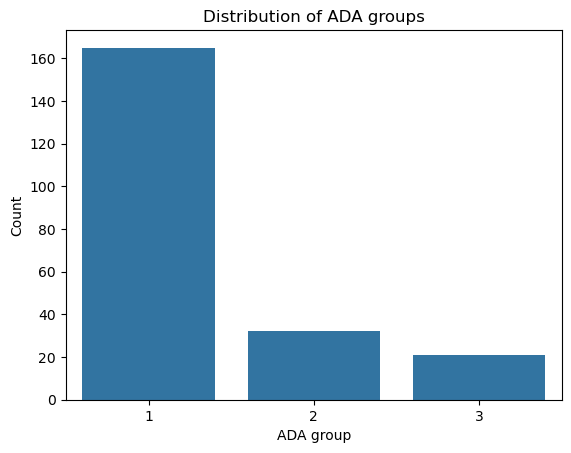

In [40]:
# plot the distribution of low, medium and high ADA percanteg
sns.countplot(
    data=computed_scors_biophi,
    x='ADA_group'
)

plt.title('Distribution of ADA groups')
plt.xlabel('ADA group')
plt.ylabel('Count')
plt.show()

In [41]:
results = []

for col in computed_scors_biophi.columns[2:18]:  # index 2 to 17 inclusive
    sub_df = computed_scors_biophi[['ADA_group', col]]
    
    if len(sub_df) > 1:
        pearson_r, pearson_pval = pearsonr(sub_df['ADA_group'], sub_df[col])
        spearman_r, spearman_pval = spearmanr(sub_df['ADA_group'], sub_df[col])
        
        results.append({
            'variable': col,
            'pearson_r': pearson_r,
            'pearson_pval': pearson_pval,
            'spearman_r': spearman_r,
            'spearman_p': spearman_pval
        })

# Convert to DataFrame
corr_results_df = pd.DataFrame(results)

In [35]:
corr_results_df

,variable,pearson_r,pearson_pval,spearman_r,spearman_p
0,netMHC1_pep9_percentile,-0.031174,6.471375e-01,-0.013599,8.417642e-01
1,netMHC1_pep9_immunogenicity_score,-0.284989,1.932386e-05,-0.221390,9.985855e-04
2,netMHC1_pep9_preProcess,-0.058578,3.894228e-01,-0.078090,2.509236e-01
3,netMHC1_pep14_percentile,0.048853,4.730094e-01,0.049084,4.709181e-01
4,netMHC1_pep14_immunogenicity_score,-0.226467,7.560689e-04,-0.200016,3.014513e-03
5,netMHC1_pep14_preProcess,-0.090534,1.829359e-01,-0.100009,1.410692e-01
6,netMHC_II_pep12_percentile,-0.014751,8.285506e-01,-0.013685,8.407772e-01
7,netMHC_II_pep12_immunogenicity_score,0.107350,1.140005e-01,0.104597,1.236339e-01
8,netMHC_II_pep12_combined_immunogen,-0.102465,1.315143e-01,-0.074950,2.705430e-01
9,netMHC_II_pep15_percentile,0.192315,4.374455e-03,0.197983,3.330123e-03


In [42]:
# Remove som columns because I am going to train a random forest model, 
# and I dont want to have to make this many predictions when making predictions in the future
dowscaled_computed_scores = computed_scors_biophi.drop(columns=['netMHC1_pep14_percentile', 'netMHC1_pep14_immunogenicity_score', 'netMHC1_pep14_preProcess',
                                                                'netMHC_II_pep12_percentile','netMHC_II_pep12_immunogenicity_score','netMHC_II_pep12_combined_immunogen'])

# Random forest

In [68]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

auc_scores = []
recall_high_scores = []

X = dowscaled_computed_scores.iloc[:, 2:13]  # predictors
y = dowscaled_computed_scores['ADA_group']

model = RandomForestClassifier(n_estimators=200, random_state=12)

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)
    y_pred = model.predict(X_test)

    # Multiclass ROC AUC
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    auc_scores.append(auc)

    # Recall for HIGH (class = 3)
    recall_high = recall_score(
        y_test,
        y_pred,
        labels=[3],
        average=None
    )

    recall_high_scores.append(recall_high)

In [69]:
print("Mean ROC AUC:", np.mean(auc_scores))
print("Mean recall (high ADA):", np.mean(recall_high_scores))

Mean ROC AUC: 0.7513306784419224
Mean recall (high ADA): 0.32999999999999996


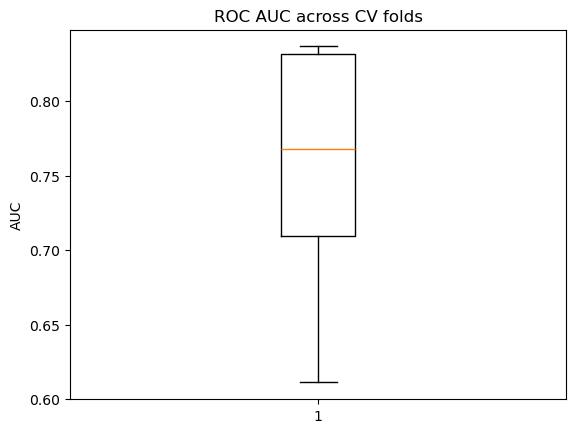

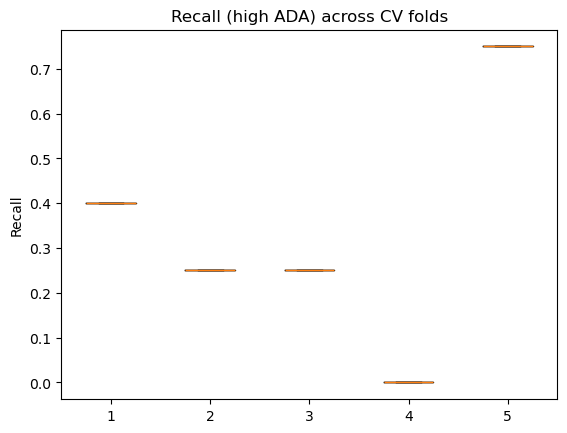

In [70]:

# AUC
plt.figure()
plt.boxplot(auc_scores)
plt.title('ROC AUC across CV folds')
plt.ylabel('AUC')
plt.show()

# Recall (high ADA)
plt.figure()
plt.boxplot(recall_high_scores)
plt.title('Recall (high ADA) across CV folds')
plt.ylabel('Recall')
plt.show()

In [71]:
from sklearn.metrics import confusion_matrix

y_true_all = []
y_pred_all = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

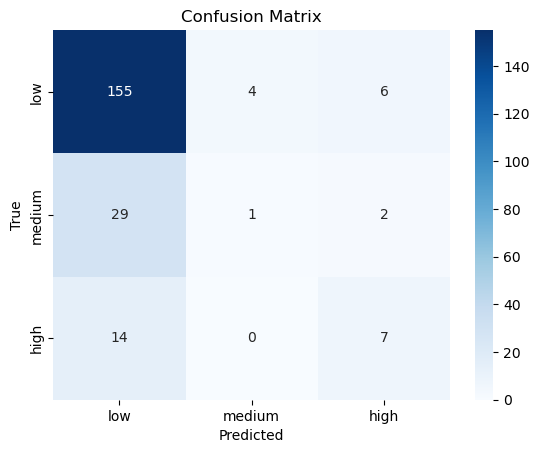

In [72]:

cm = confusion_matrix(y_true_all, y_pred_all)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low','medium','high'],
            yticklabels=['low','medium','high'])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [73]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_all = []
y_proba_all = []

for train_idx, test_idx in skf.split(X, y):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    y_true_all.extend(y.iloc[test_idx])
    y_proba_all.extend(model.predict_proba(X.iloc[test_idx]))

y_true_all = np.array(y_true_all)
y_proba_all = np.array(y_proba_all)

# Binarize labels (for ROC)
y_bin = label_binarize(y_true_all, classes=[1,2,3])

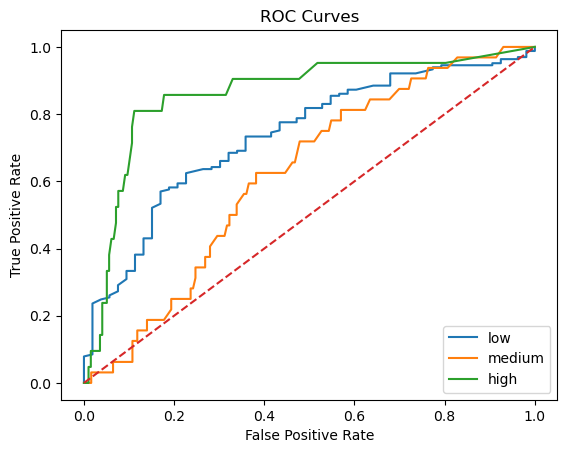

In [74]:
for i, label in enumerate(['low','medium','high']):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba_all[:, i])
    plt.plot(fpr, tpr, label=label)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()